# 02. Model Selection and Comparison

Rank candidate distributions from BestFit likelihoods and compute Akaike-weighted model-average quantiles.

In [1]:
import pythonnet
pythonnet.load("netfx")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_donet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

from RMC.BestFit import DataFrame, ExactData
from RMC.BestFit.Model import UnivariateDistribution
from Numerics.Distributions import UnivariateDistributionType

In [11]:
# Generate synthetic data
rng = np.random.default_rng(9)
years = np.arange(1970, 1970 + 60)
peaks = np.maximum(500, 9300 + 32*(years-years.min()) + rng.normal(0, 920, len(years)))

df = DataFrame()
for y, q in zip(years, peaks):
    df.ExactSeries.Add(ExactData(int(y), float(q)))
x = np.array(peaks, dtype=float)
mu, sd = float(np.mean(x)), float(np.std(x, ddof=1))

# Define candidate distributions and their parameters
specs = {
    'Normal': (UnivariateDistributionType.Normal, [mu, sd]),
    'Gumbel': (UnivariateDistributionType.Gumbel, [mu, 0.80*sd]),
    'GEV': (UnivariateDistributionType.GeneralizedExtremeValue, [mu, 0.80*sd, 0.08]),
}

# Fit each distribution, compute log-likelihood and AIC, and store results
rows=[]; models={}
for name,(dist_type,params) in specs.items():
    m=UnivariateDistribution(df,dist_type)
    p=convert_to_donet_array(params)
    m.SetParameterValues(p)
    pdf =np.array([max(1e-300,float(m.Distribution.PDF(float(v)))) for v in x],dtype=float)
    ll=m.LogLikelihood(p)
    k=len(params)
    rows.append({'model':name,'k':k,'log_likelihood':ll,'AIC':2*k-2*ll})
    models[name]=m

# Summarize results in a DataFrame sorted by AIC
summary=pd.DataFrame(rows).sort_values('AIC')
summary['delta_AIC']=summary['AIC']-summary['AIC'].min()
summary['akaike_weight']=np.exp(-0.5*summary['delta_AIC'])
summary['akaike_weight']=summary['akaike_weight']/summary['akaike_weight'].sum()
summary

,model,k,log_likelihood,AIC,delta_AIC,akaike_weight
0,Normal,2,-1.797693e+308,inf,NaN,NaN
1,Gumbel,2,-1.797693e+308,inf,NaN,NaN
2,GEV,3,-1.797693e+308,inf,NaN,NaN


In [6]:
weights=dict(zip(summary['model'], summary['akaike_weight']))
T=np.array([2,5,10,25,50,100],dtype=float)
F=1.0-1.0/T
rows=[]
for t,f in zip(T,F):
    row={'return_period':float(t)}
    qbar=0.0
    for name,m in models.items():
        q=float(m.Distribution.InverseCDF(float(f)))
        row[name]=q
        qbar += weights[name]*q
    row['model_avg']=qbar
    rows.append(row)
qtab=pd.DataFrame(rows)
qtab

,return_period,Normal,Gumbel,GEV,model_avg
0,2.0,10158.893337,10451.247881,10447.003398,NaN
1,5.0,10998.058133,11355.343030,11286.346063,NaN
2,10.0,11436.704442,11953.932687,11801.627994,NaN
3,25.0,11904.469687,12710.252305,12409.976383,NaN
4,50.0,12206.647978,13271.333403,12832.387257,NaN
5,100.0,12478.451307,13828.271566,13228.817739,NaN


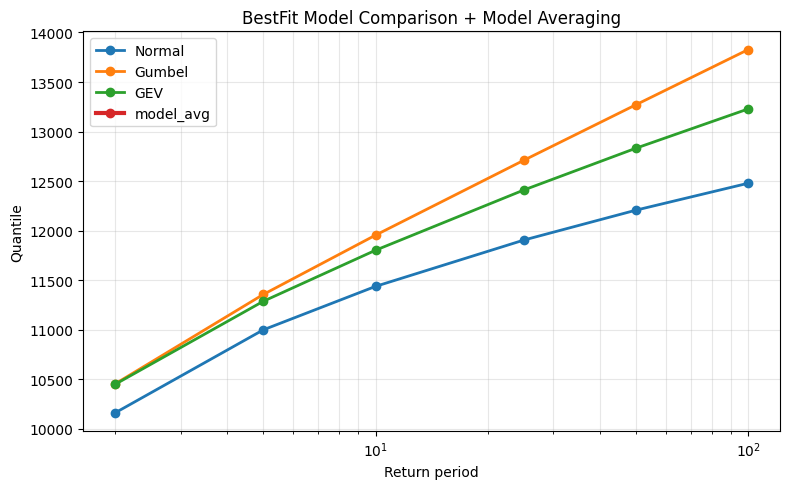

In [7]:
plt.figure(figsize=(8,5))
for c in ['Normal','Gumbel','GEV','model_avg']:
    plt.plot(qtab['return_period'], qtab[c], marker='o', lw=3 if c=='model_avg' else 2, label=c)
plt.xscale('log')
plt.xlabel('Return period')
plt.ylabel('Quantile')
plt.title('BestFit Model Comparison + Model Averaging')
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()

## Summary and Exercises

You used BestFit likelihood outputs to perform model ranking and weighted quantile aggregation.

Exercises:
1. Add BIC-based weights and compare with AIC weights.
2. Run at multiple sample sizes to assess rank stability.
3. Add uncertainty fan plots around model-average curve.